# Part 1: Data Preparation and Exploration

**1.	Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.**

**2.	Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.**

**3.	Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.**


In [45]:
import pandas as pd
import numpy as np


In [46]:
df=pd.read_csv("exchange_rate.csv")

In [47]:
df

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


In [48]:
df.isnull().sum()

,0
date,0
Ex_rate,0


In [49]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


<Axes: >

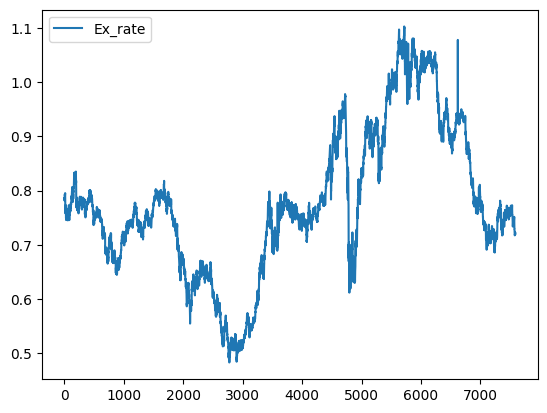

In [50]:
df.plot()

non seasonal
increasing trend
non constant

array([[<Axes: title={'center': 'Ex_rate'}>]], dtype=object)

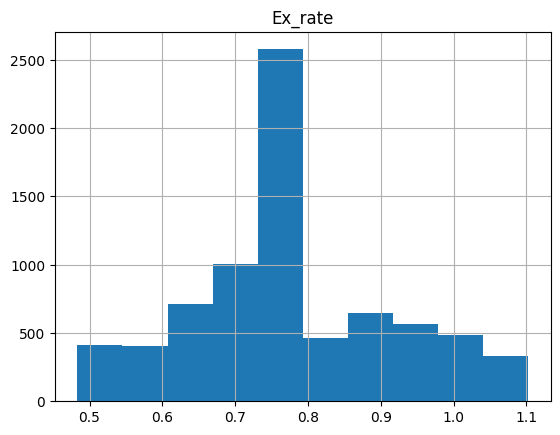

In [51]:
import matplotlib.pyplot as plt
df.hist()

In [54]:
import seaborn as sns

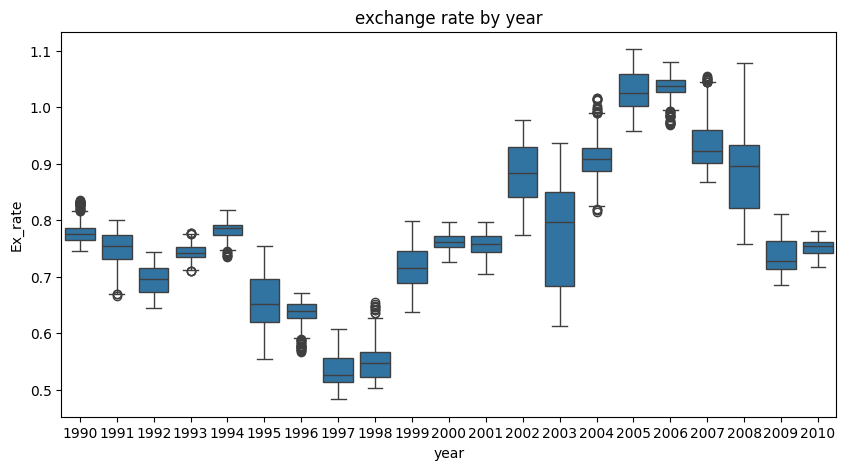

In [55]:
plt.figure(figsize=(10,5))
sns.boxplot(x='year', y='Ex_rate', data=df)
plt.title('exchange rate by year')
plt.show()

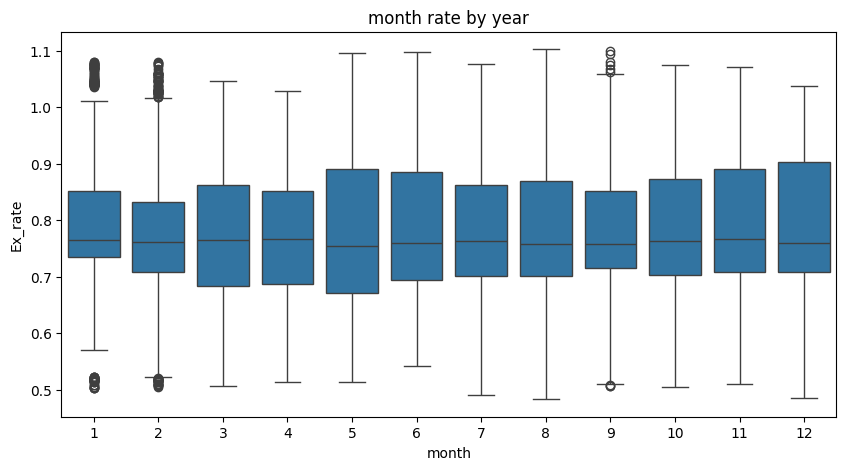

In [56]:
plt.figure(figsize=(10,5))
sns.boxplot(x='month', y='Ex_rate', data=df)
plt.title('month rate by year')
plt.show()

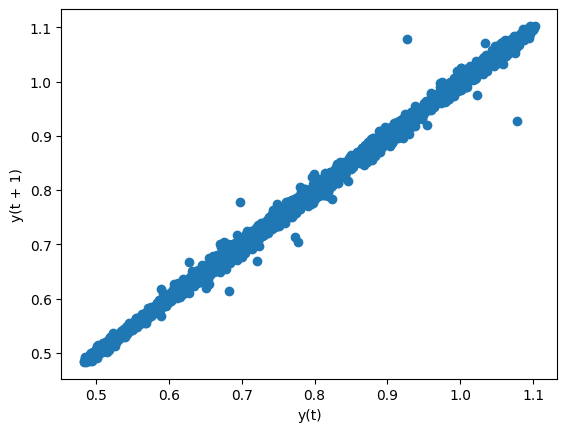

In [57]:
from pandas.plotting import lag_plot
lag_plot(df['Ex_rate'])
plt.show()

# Part 2: Model Building - ARIMA

**1.	Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.**

**2.	Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.**

**3.	Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.**

**4.	Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.**


<Figure size 1000x500 with 0 Axes>

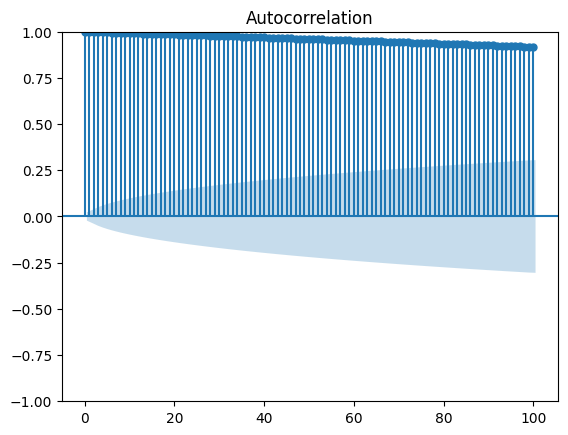

In [58]:
plt.figure(figsize=(10,5))
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df['Ex_rate'],lags=100)
plt.show()





<Figure size 1000x500 with 0 Axes>

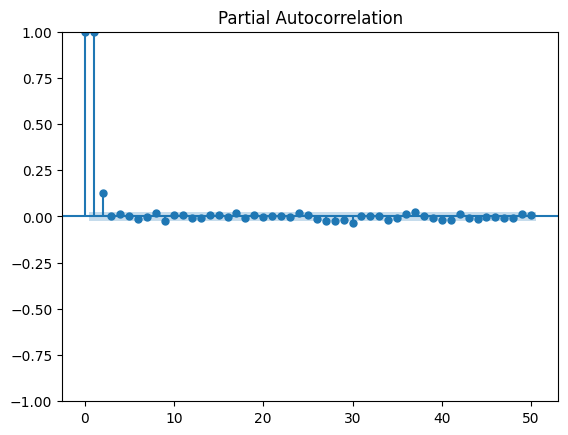

In [59]:
plt.figure(figsize=(10,5))
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(df['Ex_rate'],lags=50)
plt.show()

In [60]:
from statsmodels.tsa.stattools import adfuller
def adf_test(df):
    result=adfuller(df)
    return{
      'adf_statistic':result[0],
      'p_value':result[1],
      'critical_values':result[4]
        }

In [61]:
adf_test_org=adf_test(df['Ex_rate'])
adf_test_org

{'adf_statistic': np.float64(-1.6649941807382342),
 'p_value': np.float64(0.4492327353597477),
 'critical_values': {'1%': np.float64(-3.4312123140180137),
  '5%': np.float64(-2.861921078147796),
  '10%': np.float64(-2.5669728434336108)}}

non stationary data

In [62]:
df_dif=df['Ex_rate'].diff().dropna()
df_dif.head()

,Ex_rate
1,-0.0037
2,0.0049
3,-0.0007
4,-0.0011
5,0.0017


In [63]:
adf_test_dif=adf_test(df_dif)
adf_test_dif

{'adf_statistic': np.float64(-99.39343120118632),
 'p_value': 0.0,
 'critical_values': {'1%': np.float64(-3.4312123140180137),
  '5%': np.float64(-2.861921078147796),
  '10%': np.float64(-2.5669728434336108)}}

stationary after diff

In [99]:
train_size = int(len(df) * 0.8)
train, test = df[:train_size], df[train_size:].copy()

print("Train data length:", len(train))
print("Test data length:", len(test))

Train data length: 6070
Test data length: 1518


In [74]:
arima_model=ARIMA(train['Ex_rate'], order=(1,1,1))
model_arima=arima_model.fit()
summary=model_arima.summary()
print(summary)
print('aic:',model_arima.aic)
print('bic',model_arima.bic)
mse_arima=np.sqrt(mean_squared_error(train['Ex_rate'],model_arima.predict()))
print('mse_arima:',mse_arima)

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Fri, 06 Mar 2026   AIC                         -45432.092
Time:                        07:37:26   BIC                         -45411.959
Sample:                             0   HQIC                        -45425.104
                               - 6070                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

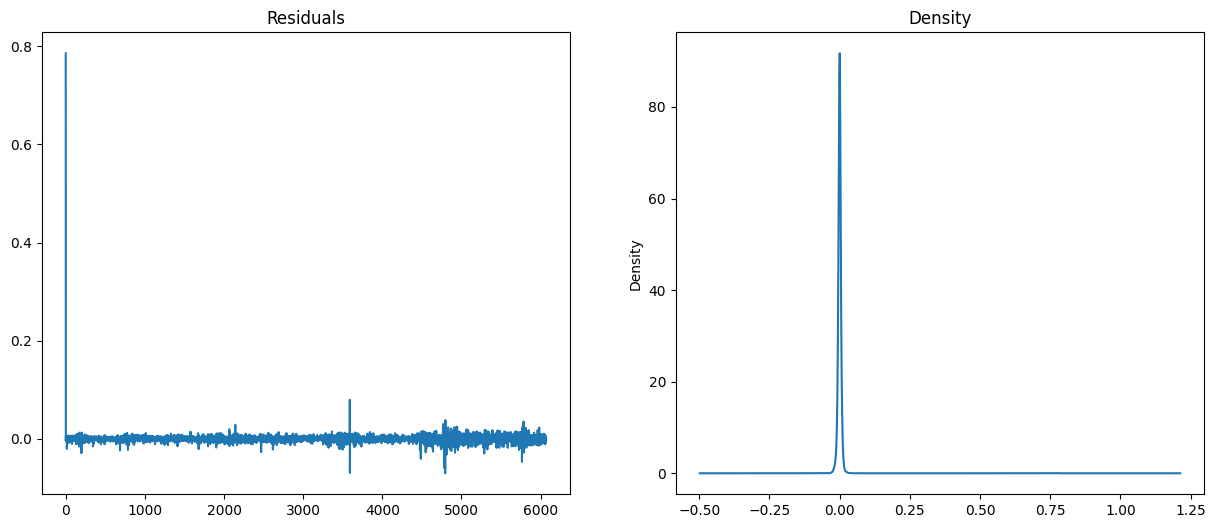

In [75]:

residuals = model_arima.resid
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(kind='kde', title='Density', ax=ax[1])
plt.show()

In [76]:
start_index = len(train)
end_index = len(train) + len(test) - 1
predictions = model_arima.predict(start=start_index, end=end_index, typ='levels')

# Combine the predictions with test data for comparison
test['Predictions'] = predictions


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
/tmp/ipykernel_952/994637198.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = predictions


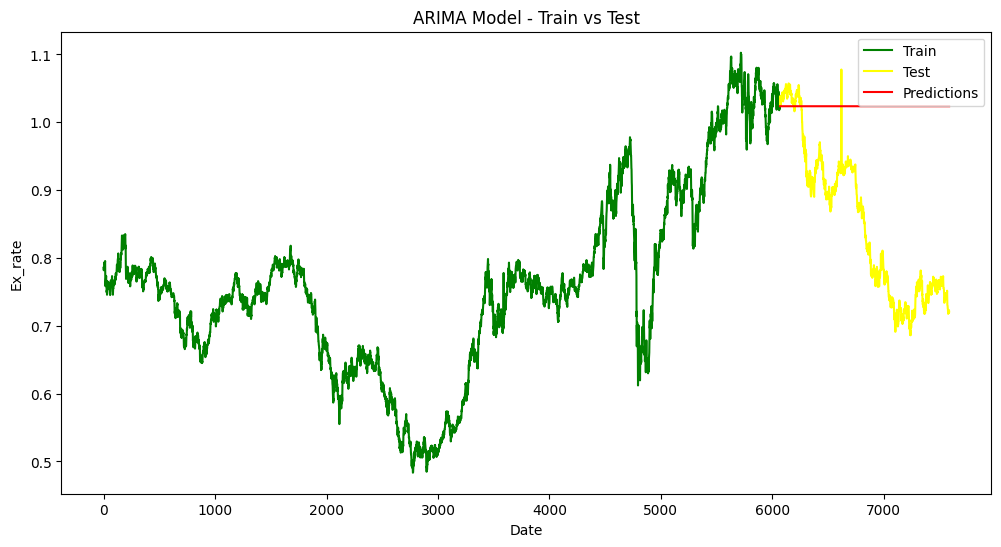

In [77]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train['Ex_rate'], label='Train',color='green')
plt.plot(test.index, test['Ex_rate'], label='Test',color='yellow')
plt.plot(test.index, test['Predictions'], label='Predictions', color='red')
plt.xlabel('Date')
plt.ylabel('Ex_rate')
plt.title('ARIMA Model - Train vs Test')
plt.legend()
plt.show()

In [78]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [79]:
mse=mean_squared_error(test['Ex_rate'],test['Predictions'])
print('mse:',mse)
mae=mean_absolute_error(test['Ex_rate'],test['Predictions'])
print('mae:',mae)

mse: 0.04220423630856161
mae: 0.17770970449121345


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-45426.730, Time=8.60 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-45404.538, Time=0.93 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-45424.276, Time=0.72 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-45423.258, Time=2.50 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-45406.255, Time=0.29 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-45428.463, Time=10.50 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-45424.717, Time=7.90 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-45430.403, Time=4.74 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-45398.539, Time=2.42 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-45425.953, Time=1.46 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-45432.092, Time=1.19 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-45424.940, Time=1.33 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-45425.957, Time=0.68 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=-45400.258, Time=1.38 sec
 ARI

/tmp/ipykernel_952/1516226153.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = predictions


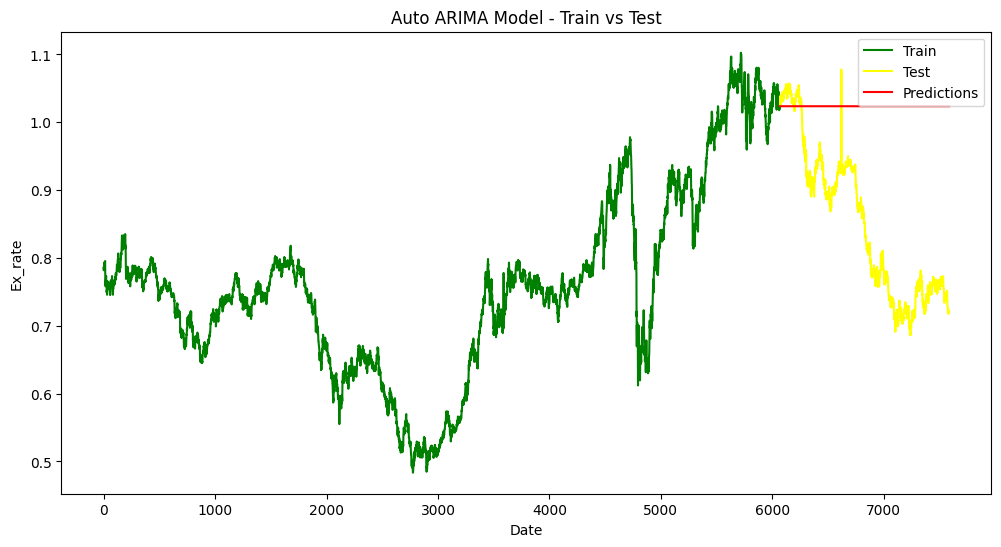

Mean Squared Error (MSE): 0.04220423630856161
Mean Absolute Error (MAE): 0.17770970449121345


In [82]:
!pip install pmdarima
import pmdarima as pm

# Train auto ARIMA on the training data
model = pm.auto_arima(train['Ex_rate'], seasonal=False, trace=True)

# Forecast for the test set length
predictions = model.predict(n_periods=len(test))

# Combine the predictions with test data for comparison
test['Predictions'] = predictions

# Plot the results
plt.figure(figsize=(12,6))
plt.plot(train.index, train['Ex_rate'], label='Train',color='green')
plt.plot(test.index, test['Ex_rate'], label='Test',color='yellow')
plt.plot(test.index, test['Predictions'], label='Predictions', color='red')
plt.xlabel('Date')
plt.ylabel('Ex_rate')
plt.title('Auto ARIMA Model - Train vs Test')
plt.legend()
plt.show()

# Evaluate the model
mse = mean_squared_error(test['Ex_rate'], test['Predictions'])
mae = mean_absolute_error(test['Ex_rate'], test['Predictions'])

print(f'Mean Squared Error (MSE): {mse}')
print(f'Mean Absolute Error (MAE): {mae}')

# Part 3: Model Building - Exponential Smoothing

**1.	Model Selection: Depending on the time series characteristics, choose an appropriate Exponential Smoothing model (Simple, Holt’s Linear, or Holt-Winters).**

**2.	Parameter Optimization: Use techniques such as grid search or AIC to find the optimal parameters for the smoothing levels and components.**

**3.	Model Fitting and Forecasting: Fit the chosen Exponential Smoothing model and forecast future values. Compare these forecasts visually with the actual data.**


In [84]:
from statsmodels.tsa.holtwinters import  ExponentialSmoothing
holts_model=ExponentialSmoothing(train['Ex_rate'],trend='add')
holts_result=holts_model.fit()

In [86]:
print(holts_result.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                  Ex_rate   No. Observations:                 6070
Model:             ExponentialSmoothing   SSE                              0.199
Optimized:                         True   AIC                         -62655.663
Trend:                         Additive   BIC                         -62628.819
Seasonal:                          None   AICC                        -62655.650
Seasonal Periods:                  None   Date:                 Fri, 06 Mar 2026
Box-Cox:                          False   Time:                         07:47:39
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.9428890                alpha                 True
smoothing_trend             0.0000

In [89]:
holts_model_opt=ExponentialSmoothing(train['Ex_rate'],trend='add')
holts_result_opt=holts_model_opt.fit()


In [92]:
print(holts_result_opt.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                  Ex_rate   No. Observations:                 6070
Model:             ExponentialSmoothing   SSE                              0.199
Optimized:                         True   AIC                         -62655.663
Trend:                         Additive   BIC                         -62628.819
Seasonal:                          None   AICC                        -62655.650
Seasonal Periods:                  None   Date:                 Fri, 06 Mar 2026
Box-Cox:                          False   Time:                         07:50:27
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.9428890                alpha                 True
smoothing_trend             0.0000

In [97]:
holt_forecast=holts_result_opt.forecast(steps=len(test))
test['Holt_Predictions'] = holt_forecast

/tmp/ipykernel_952/2786892643.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Holt_Predictions'] = holt_forecast


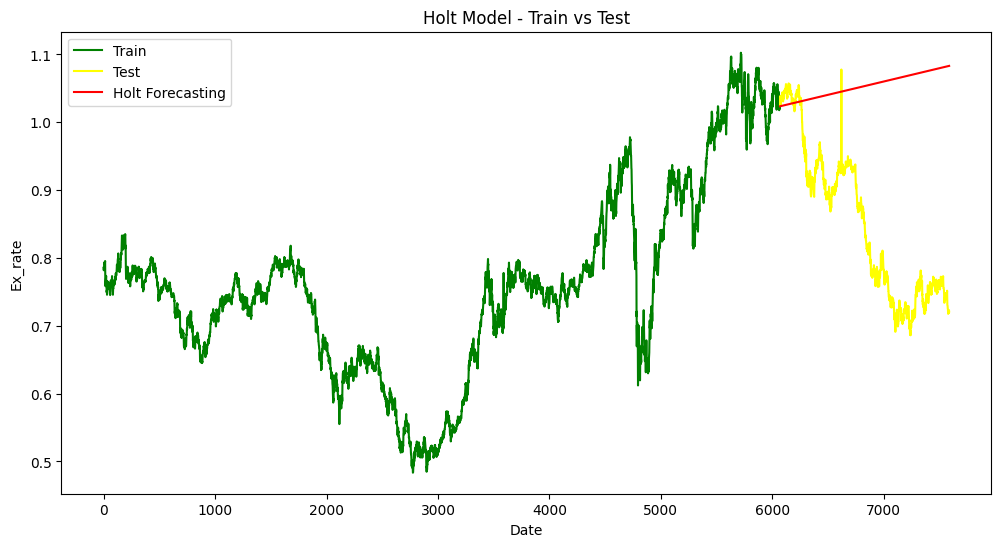

In [98]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train['Ex_rate'], label='Train',color='green')
plt.plot(test.index, test['Ex_rate'], label='Test',color='yellow')
plt.plot(test.index, test['Holt_Predictions'], label='Holt Forecasting', color='red')

plt.xlabel('Date')
plt.ylabel('Ex_rate')
plt.title('Holt Model - Train vs Test')
plt.legend()
plt.show()

In [101]:
test['Holt_Predictions'] = holt_forecast # Re-assign to ensure the column exists
mse_holt=mean_squared_error(test['Ex_rate'],test['Holt_Predictions'])
print('Holt MSE:',mse_holt)
mae_holt=mean_absolute_error(test['Ex_rate'],test['Holt_Predictions'])
print('Holt MAE:',mae_holt)

Holt MSE: 0.057170929219329945
Holt MAE: 0.20659619114093827


### Conclusion: Model Performance for Exchange Rate Forecasting

 The models were trained on 80% of the data and tested on the remaining 20%.

**Summary of Performance Metrics:**

*   **ARIMA Model (Auto ARIMA):**
    *   Mean Squared Error (MSE): 0.0422
    *   Mean Absolute Error (MAE): 0.1777

*   **Holt's Exponential Smoothing Model:**
    *   Mean Squared Error (MSE): 0.0572
    *   Mean Absolute Error (MAE): 0.2066

**Comparison :**

Upon comparing the error metrics, the **ARIMA model (specifically, the Auto ARIMA model)**  performed with lower MSE and MAE values. This suggests that for this particular exchange rate time series, the ARIMA model was more accurate in its predictions over the test period.

*   **ARIMA Advantages:**
 The lower error metrics indicate that ARIMA was better able to capture the underlying patterns, trends, and differencing required for stationarity

*   **Holt's Exponential Smoothing Limitations:** While Holt's model is effective for data with trends, its performance was slightly less accurate than ARIMA in this case.

** Conclusion:**

the **ARIMA model** proved to be the more robust and accurate choice, yielding lower forecasting errors. The choice of `(1,1,1)` for the ARIMA model (as determined by `auto_arima`)